In [ ]:
!pip install -q pyspark

In [ ]:
from google.colab import drive

# General purpose
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def find_project_folder(folder_name="CineFusion", base_path="/content/drive/MyDrive"):
    for root, dirs, files in os.walk(base_path):
        if folder_name in dirs:
            return os.path.join(root, folder_name)
    return None

BASE_DIR = find_project_folder()

if BASE_DIR is None:
    raise Exception("Project folder not found. Make sure it's added to MyDrive.")

print("Project folder found at:", BASE_DIR)

Project folder found at: /content/drive/MyDrive/CineFusion


#**Movie Lens 25 M Data**

Checking Movie Lens 25 M data features and quality

25000095 ratings (User generated)

1093360 tags (User generated)

62423 movies

162541 users

In [ ]:
ml25M_genome_scores_raw = pd.read_csv(BASE_DIR + "/ml-25m/genome-scores.csv")
ml25M_genome_tags_raw = pd.read_csv(BASE_DIR + "/ml-25m/genome-tags.csv")
ml25M_links_raw = pd.read_csv(BASE_DIR + "/ml-25m/links.csv")
ml25M_movies_raw = pd.read_csv(BASE_DIR + "/ml-25m/movies.csv")
ml25M_ratings_raw = pd.read_csv(BASE_DIR + "/ml-25m/ratings.csv")
ml25M_tags_raw = pd.read_csv(BASE_DIR + "/ml-25m/tags.csv")

In [ ]:
print(ml25M_genome_scores_raw.head(), "\n")

   movieId  tagId  relevance
0        1      1    0.02875
1        1      2    0.02375
2        1      3    0.06250
3        1      4    0.07575
4        1      5    0.14075 



In [ ]:
print(ml25M_genome_tags_raw.head(), "\n")

   tagId           tag
0      1           007
1      2  007 (series)
2      3  18th century
3      4         1920s
4      5         1930s 



In [ ]:
print(ml25M_links_raw.head(), "\n")

   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0 



In [ ]:
print(ml25M_movies_raw.head(), "\n")

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy   



In [ ]:
print(ml25M_ratings_raw.head(), "\n")

   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510 



In [ ]:
print(ml25M_tags_raw.head(), "\n")

   userId  movieId               tag   timestamp
0       3      260           classic  1439472355
1       3      260            sci-fi  1439472256
2       4     1732       dark comedy  1573943598
3       4     1732    great dialogue  1573943604
4       4     7569  so bad it's good  1573943455 



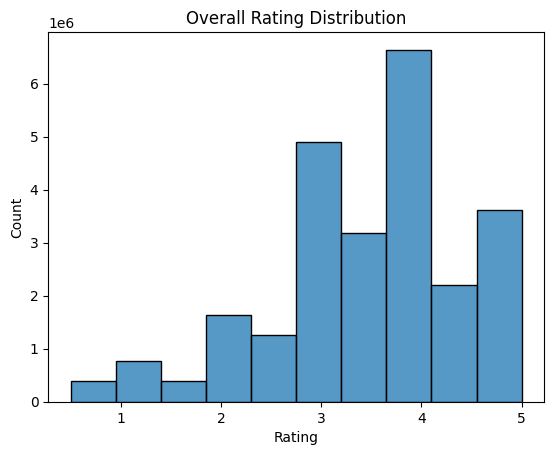

In [ ]:
sns.histplot(ml25M_ratings_raw['rating'], bins=10)
plt.title("Overall Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [ ]:
user_counts = ml25M_ratings_raw.groupby('userId')['rating'].count()

max_ratings = user_counts.max()
max_user = user_counts.idxmax()  # userId of the max
print(f"User {max_user} rated the maximum number of movies: {max_ratings}")

bins = list(range(0, 40001, 1000))
labels = [f"{i+1}-{i+1000}" for i in range(0, 40000, 1000)]

user_buckets = pd.cut(user_counts, bins=bins, labels=labels, right=True)

bucket_counts = user_buckets.value_counts().sort_index()

print("\nUser Rating Buckets:")
for bucket, count in bucket_counts.items():
    print(f"{bucket}: {count} users")

User 72315 rated the maximum number of movies: 32202

User Rating Buckets:
1-1000: 159871 users
1001-2000: 2236 users
2001-3000: 310 users
3001-4000: 78 users
4001-5000: 28 users
5001-6000: 10 users
6001-7000: 3 users
7001-8000: 2 users
8001-9000: 1 users
9001-10000: 1 users
10001-11000: 0 users
11001-12000: 0 users
12001-13000: 0 users
13001-14000: 0 users
14001-15000: 0 users
15001-16000: 0 users
16001-17000: 0 users
17001-18000: 0 users
18001-19000: 0 users
19001-20000: 0 users
20001-21000: 0 users
21001-22000: 0 users
22001-23000: 0 users
23001-24000: 0 users
24001-25000: 0 users
25001-26000: 0 users
26001-27000: 0 users
27001-28000: 0 users
28001-29000: 0 users
29001-30000: 0 users
30001-31000: 0 users
31001-32000: 0 users
32001-33000: 1 users
33001-34000: 0 users
34001-35000: 0 users
35001-36000: 0 users
36001-37000: 0 users
37001-38000: 0 users
38001-39000: 0 users
39001-40000: 0 users


In [ ]:
dfs = {
    "genome_scores": ml25M_genome_scores_raw,
    "genome_tags": ml25M_genome_tags_raw,
    "links": ml25M_links_raw,
    "movies": ml25M_movies_raw,
    "ratings": ml25M_ratings_raw,
    "tags": ml25M_tags_raw
}

for name, df in dfs.items():
    print(f"\n==== {name.upper()} ====")

    null_mask = df.isnull()

    empty_mask = df.select_dtypes(include="object").apply(
        lambda col: col.str.strip() == ""
    )

    combined_mask = null_mask | empty_mask

    bad_rows = df[combined_mask.any(axis=1)]

    print(f"Rows with NULL/empty/blank values: {len(bad_rows)}")

    if len(bad_rows) > 0:
        print(bad_rows.to_string(index=False))


==== GENOME_SCORES ====
Rows with NULL/empty/blank values: 0

==== GENOME_TAGS ====
Rows with NULL/empty/blank values: 0

==== LINKS ====
Rows with NULL/empty/blank values: 107
 movieId   imdbId  tmdbId
     721   114103     NaN
     730   125877     NaN
     770    38426     NaN
     791   113610     NaN
    1107   102336     NaN
    1142   116403     NaN
    1316   115548     NaN
    1421   113212     NaN
    1434   123281     NaN
    1630   123953     NaN
    1738   120881     NaN
    1774   133090     NaN
    1789   114322     NaN
    2230   133361     NaN
    2258    87690     NaN
    2270   109390     NaN
    2588   341315     NaN
    2851    81454     NaN
    4051    56600     NaN
    5565   309521     NaN
    5738   223249     NaN
    7145   348862     NaN
    7568   253016     NaN
   26587    92337     NaN
   32600   377059     NaN
   48713   835046     NaN
   67852   419477     NaN
   68533  1359583     NaN
   68544    79914     NaN
   69201   230992     NaN
   70800  114148

In [ ]:
duplicate_rows = ml25M_ratings_raw.duplicated(subset=['userId', 'movieId', 'rating'])
num_duplicates = duplicate_rows.sum()

print(f"Number of duplicate ratings: {num_duplicates}")

Number of duplicate ratings: 0
